In [1]:
import numpy as np
import pandas as pd

In [2]:
import numpy as np

X_train = np.load(r'/content/ModelingReady_X_train.npy', allow_pickle=True)
X_val   = np.load(r'/content/ModelingReady_X_val.npy', allow_pickle=True)

y_train = np.load(r'/content/ModelingReady_y_train.npy', allow_pickle=True)
y_val   = np.load(r'/content/ModelingReady_y_val.npy', allow_pickle=True)


In [3]:
import joblib
tokenizer = joblib.load('/content/input_tokenizer.pkl')

In [4]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train =  pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen=40,  # covers 99% of your data with minimal padding waste
    padding='post',
    truncating='post'
)

X_val =  pad_sequences(
    tokenizer.texts_to_sequences(X_val),
    maxlen=40,  # covers 99% of your data with minimal padding waste
    padding='post',
    truncating='post'
)

# X_test =  pad_sequences(
#     tokenizer.texts_to_sequences(X_test),
#     maxlen=40,  # covers 99% of your data with minimal padding waste
#     padding='post',
#     truncating='post'
# )

In [5]:
!pip install keras_tuner
!pip install keras_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.3 MB/s eta 0:00:00


In [6]:
import tensorflow as tf
import tensorflow.keras as keras
from keras.layers import *
from keras.models import Model
import keras_tuner as kt

In [ ]:
word2vec_weights = np.load(r'/content/word2vec_input_embedding_matrix.npy')

# Transformer Encoder

15184

In [ ]:
import keras_hub as kb

In [ ]:
from keras_hub.layers import TransformerEncoder, TokenAndPositionEmbedding

In [ ]:
from keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense
from keras.models import Model
from keras.initializers import Constant
from keras_hub.layers import PositionEmbedding, TransformerEncoder

encoder_inp = Input(shape=(40,), name='Encoder_Input')

# 1. Embeddings
token_emb = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    embeddings_initializer=Constant(word2vec_weights),
    trainable=True,
    mask_zero=True,
    name='Token_Embedding'
)(encoder_inp)

pos_emb = PositionEmbedding(sequence_length=40, name='Position_Embedding')(token_emb)
token_and_position_emb = token_emb + pos_emb

# 2. Transformer Encoder Blocks
encoder_1 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05)(token_and_position_emb)
encoder_2 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05)(encoder_1)

# 3. FIX: Pool the 3D output (None, 40, 300) into a 2D output (None, 300)
# This layer correctly respects the 'mask_zero=True' padding mask
pooled_output = GlobalAveragePooling1D()(encoder_2)

# 4. FIX: Add your final classification layer
# Replace 'num_classes' with your actual number of classes (e.g., 2 for binary, or N for multiclass)
num_classes = 3
classification_output = Dense(num_classes, activation='softmax', name='Classification_Head')(pooled_output)

# Create the final compiled model
Encoder_model = Model(inputs=[encoder_inp], outputs=[classification_output], name='Transformer_Classifier')


In [ ]:
# Compile
Encoder_model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Encoder_model.summary()




Model: "Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Token_Embedding     │ (None, 40, 300)   │  4,555,500 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Position_Embedding  │ (None, 40, 300)   │     12,000 │ Token_Embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 40, 300)   │          0 │ Token_Embedding[… │
│                     │                   │            │ Position_Embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ add_3[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Head │ (None, 3)         │        903 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,755,499 (29.58 MB)

 Trainable params: 7,755,499 (29.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import *
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)
# ck_all = tf.keras.callbacks.ModelCheckpoint(
#     filepath='/content/Model1_saved/epoch_{epoch:02d}.keras',
#     monitor='val_accuracy',
#     save_best_only=False,   # save every epoch, not just best
#     verbose=1)


# ck = tf.keras.callbacks.ModelCheckpoint(
#     '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=False,verbose=1
# )

history = Encoder_model.fit(
                  X_train, y_train, validation_data = (X_val,y_val)
                  ,epochs = 20, callbacks = [e1,e2], batch_size = 128, verbose = 1
              )



Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 209ms/step - accuracy: 0.5796 - loss: 1.5512 - val_accuracy: 0.6421 - val_loss: 0.9208
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6166 - loss: 0.9674 - val_accuracy: 0.6421 - val_loss: 0.8918
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6459 - loss: 0.9268 - val_accuracy: 0.6541 - val_loss: 0.9736
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.6500 - loss: 0.8935 - val_accuracy: 0.6707 - val_loss: 0.7756
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6984 - loss: 0.7601 - val_accuracy: 0.6879 - val_loss: 0.7267
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.7255 - loss: 0.6780 - val_accuracy: 0.7548 - val_loss: 0.6502
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.7672 - loss: 0.5809 - val_accuracy: 0.7992 - val_loss: 0.5502
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.8163 - loss: 0.4725 - val_accuracy: 0.7400 -

# Applying Regularization

In [ ]:
def build_model(hp):

  encoder_inp = Input(shape=(40,), name='Encoder_Input')

  # 1. Embeddings
  token_emb = Embedding(
      input_dim=len(tokenizer.word_index) + 1,
      output_dim=300,
      embeddings_initializer=Constant(word2vec_weights),
      trainable=True,
      mask_zero=True,
      name='Token_Embedding'
  )(encoder_inp)

  pos_emb = PositionEmbedding(sequence_length=40, name='Position_Embedding')(token_emb)
  token_and_position_emb = token_emb + pos_emb

  # 2. Transformer Encoder Blocks
  encoder_1 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout = hp.Choice('Self_attention1', [0.1,0.3,0.2]))(token_and_position_emb)
  encoder_2 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout = hp.Choice('Self_attention2', [0.1,0.3,0.2]))(encoder_1)

  # 3. FIX: Pool the 3D output (None, 40, 300) into a 2D output (None, 300)
  # This layer correctly respects the 'mask_zero=True' padding mask
  pooled_output = GlobalAveragePooling1D()(encoder_2)

  # Dense
  num_classes = 3
  classification_output = Dense(num_classes, activation='softmax', name='Classification_Head')(pooled_output)

  # Create the final compiled model
  Encoder_model = Model(inputs=[encoder_inp], outputs=[classification_output], name='Transformer_Classifier')

  # Compile
  Encoder_model.compile(
          loss='sparse_categorical_crossentropy',
          metrics=['accuracy']
      )

  return Encoder_model


In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=8,             # keep small given slow non-cuDNN LSTM training
    executions_per_trial=1,
    directory='tuner_results',
    project_name='Encoder_search',
    overwrite=True
)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005
)

ck = tf.keras.callbacks.ModelCheckpoint(
    '/content/Model_saved/best_encoder.keras', monitor='val_accuracy', save_best_only=True,verbose=1
)


In [ ]:

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=6,
    callbacks=[e1,e2]
)

Trial 8 Complete [00h 00m 55s]
val_loss: 1.0023316144943237

Best val_loss So Far: 0.5323817133903503
Total elapsed time: 00h 06m 40s


In [ ]:
tuner.get_best_hyperparameters()[0].values

{'Self_attention1': 0.2, 'Self_attention2': 0.2}

# Best model

In [ ]:

encoder_inp = Input(shape=(40,), name='Encoder_Input')

# 1. Embeddings
token_emb = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    embeddings_initializer=Constant(word2vec_weights),
    trainable=True,
    mask_zero=True,
    name='Token_Embedding'
)(encoder_inp)

pos_emb = PositionEmbedding(sequence_length=40, name='Position_Embedding')(token_emb)
token_and_position_emb = token_emb + pos_emb

# 2. Transformer Encoder Blocks
encoder_1 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout=0.2)(token_and_position_emb)
encoder_2 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout=0.2)(encoder_1)

# 3. FIX: Pool the 3D output (None, 40, 300) into a 2D output (None, 300)
# This layer correctly respects the 'mask_zero=True' padding mask
pooled_output = GlobalAveragePooling1D()(encoder_2)

# 4. FIX: Add your final classification layer
# Replace 'num_classes' with your actual number of classes (e.g., 2 for binary, or N for multiclass)
num_classes = 3
classification_output = Dense(num_classes, activation='softmax', name='Classification_Head')(pooled_output)

# Create the final compiled model
Encoder_model = Model(inputs=[encoder_inp], outputs=[classification_output], name='Transformer_Classifier')
# Compile
Encoder_model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Encoder_model.summary()




Model: "Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Token_Embedding     │ (None, 40, 300)   │  4,555,500 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Position_Embedding  │ (None, 40, 300)   │     12,000 │ Token_Embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 40, 300)   │          0 │ Token_Embedding[… │
│                     │                   │            │ Position_Embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ add_3[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Head │ (None, 3)         │        903 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,755,499 (29.58 MB)

 Trainable params: 7,755,499 (29.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005, verbose=1
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005, verbose=1
)
ck_all = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/Model3_saved/epoch_{epoch:02d}.keras',
    monitor='val_accuracy',
    save_best_only=False,   # save every epoch, not just best
    verbose=1)


# ck = tf.keras.callbacks.ModelCheckpoint(
    # '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=False,verbose=1
# )

In [ ]:
Encoder_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    callbacks=[e1,e2,ck_all]
)

Epoch 1/20
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5826 - loss: 1.6712
Epoch 1: saving model to /content/Model3_saved/epoch_01.keras

Epoch 1: finished saving model to /content/Model3_saved/epoch_01.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 36s 170ms/step - accuracy: 0.6064 - loss: 1.1653 - val_accuracy: 0.6421 - val_loss: 1.4620
Epoch 2/20
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6322 - loss: 0.9452
Epoch 2: saving model to /content/Model3_saved/epoch_02.keras

Epoch 2: finished saving model to /content/Model3_saved/epoch_02.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - accuracy: 0.6330 - loss: 0.9258 - val_accuracy: 0.2156 - val_loss: 1.2650
Epoch 3/20
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6252 - loss: 0.8975
Epoch 3: saving model to /content/Model3_saved/epoch_03.keras

Epoch 3: finished saving model to /content/Model3_saved/epoch_03.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 13s 99ms/step - accuracy: 0.6671 - loss: 0.8285 - val_accuracy: 0.654

In [ ]:
df_tf = pd.DataFrame(Encoder_model.history.history)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

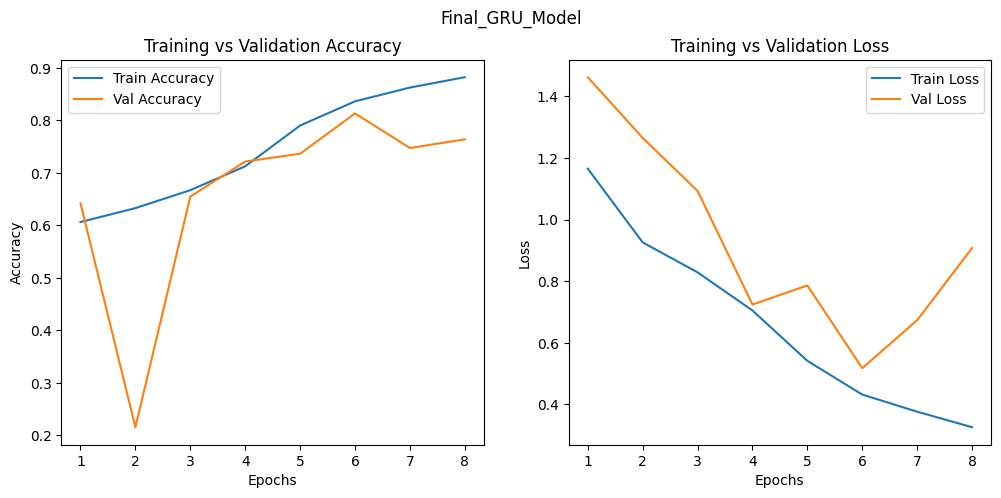

,accuracy,loss,val_accuracy,val_loss
0,0.606413,1.165293,0.642128,1.462002
1,0.632957,0.925802,0.215569,1.264974
2,0.667136,0.828543,0.654808,1.092724
3,0.712591,0.704667,0.721733,0.724027
4,0.790228,0.541202,0.736527,0.785924
5,0.836387,0.431720,0.813315,0.517311
6,0.862579,0.376150,0.747446,0.673305
7,0.882311,0.325740,0.764001,0.907517


In [ ]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['val_accuracy'], label='Val Accuracy')
# sns.lineplot(x=[5,5],y = [0.7,1],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['loss'], label='Train Loss')
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['val_loss'], label='Val Loss')
# sns.lineplot(x=[5,5],y = [0.3,0.7],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.suptitle('Final_GRU_Model')
plt.show()

df_tf

In [ ]:
# Choosing epoch 6 weights as final

In [ ]:
import tensorflow as tf

# Load the model from epoch 6
model_epoch6 = tf.keras.models.load_model('/content/Model3_saved/epoch_06.keras')

# Check summary to confirm
model_epoch6.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Token_Embedding     │ (None, 40, 300)   │  4,555,500 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Position_Embedding  │ (None, 40, 300)   │     12,000 │ Token_Embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 40, 300)   │          0 │ Token_Embedding[… │
│                     │                   │            │ Position_Embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ add_3[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Head │ (None, 3)         │        903 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,511,000 (59.17 MB)

 Trainable params: 7,755,499 (29.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,755,501 (29.58 MB)

In [ ]:
import joblib
joblib.dump(model_epoch6, 'Transformer_encoder_final.pkl')

['Transformer_encoder_final.pkl']

# Training the final transformer on fast text embedding

In [7]:
fasttext_weights = np.load(r'/content/fasttext_input_embedding_matrix.npy')

In [11]:
from keras.initializers import Constant
from keras.callbacks import *
from keras_hub.layers import *

encoder_inp = Input(shape=(40,), name='Encoder_Input')

# 1. Embeddings
token_emb = Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=300,
    embeddings_initializer=Constant(fasttext_weights),
    trainable=True,
    mask_zero=True,
    name='Token_Embedding'
)(encoder_inp)

pos_emb = PositionEmbedding(sequence_length=40, name='Position_Embedding')(token_emb)
token_and_position_emb = token_emb + pos_emb

# 2. Transformer Encoder Blocks
encoder_1 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout=0.2)(token_and_position_emb)
encoder_2 = TransformerEncoder(intermediate_dim=2048, num_heads=6, activation='relu', layer_norm_epsilon=1e-05, dropout=0.2)(encoder_1)

# 3. FIX: Pool the 3D output (None, 40, 300) into a 2D output (None, 300)
# This layer correctly respects the 'mask_zero=True' padding mask
pooled_output = GlobalAveragePooling1D()(encoder_2)

# 4. FIX: Add your final classification layer
# Replace 'num_classes' with your actual number of classes (e.g., 2 for binary, or N for multiclass)
num_classes = 3
classification_output = Dense(num_classes, activation='softmax', name='Classification_Head')(pooled_output)

# Create the final compiled model
Encoder_model_ft = Model(inputs=[encoder_inp], outputs=[classification_output], name='Transformer_Classifier')
# Compile
Encoder_model_ft.compile(
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Encoder_model_ft.summary()




/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Transformer_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Token_Embedding     │ (None, 40, 300)   │  4,555,500 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Position_Embedding  │ (None, 40, 300)   │     12,000 │ Token_Embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 40, 300)   │          0 │ Token_Embedding[… │
│                     │                   │            │ Position_Embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 40, 300)   │  1,593,548 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Classification_Head │ (None, 3)         │        903 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,755,499 (29.58 MB)

 Trainable params: 7,755,499 (29.58 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
e1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True,min_delta=0.005, verbose=1
)
e2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=2, restore_best_weights=True,min_delta=0.005, verbose=1
)
ck_all = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/Modelft_saved/epoch_{epoch:02d}.keras',
    monitor='val_accuracy',
    save_best_only=False,   # save every epoch, not just best
    verbose=1)


# ck = tf.keras.callbacks.ModelCheckpoint(
    # '/content/Model_saved/best_gru.keras', monitor='val_accuracy', save_best_only=False,verbose=1
# )

In [14]:
Encoder_model_ft.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    epochs=20,
    callbacks=[e1,e2,ck_all]
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'Position_Embedding' (of type PositionEmbedding) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.5406 - loss: 1.6975
Epoch 1: saving model to /content/Modelft_saved/epoch_01.keras

Epoch 1: finished saving model to /content/Modelft_saved/epoch_01.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 51s 273ms/step - accuracy: 0.5947 - loss: 1.1726 - val_accuracy: 0.1423 - val_loss: 1.8749
Epoch 2/20
132/134 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6106 - loss: 0.9573
Epoch 2: saving model to /content/Modelft_saved/epoch_02.keras

Epoch 2: finished saving model to /content/Modelft_saved/epoch_02.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 15s 112ms/step - accuracy: 0.6320 - loss: 0.9271 - val_accuracy: 0.1423 - val_loss: 1.2730
Epoch 3/20
133/134 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6234 - loss: 0.9220
Epoch 3: saving model to /content/Modelft_saved/epoch_03.keras

Epoch 3: finished saving model to /content/Modelft_saved/epoch_03.keras
134/134 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.6413 - loss: 0.9076 - val_accuracy: 0.6421 

In [15]:
df_tf = pd.DataFrame(Encoder_model_ft.history.history)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

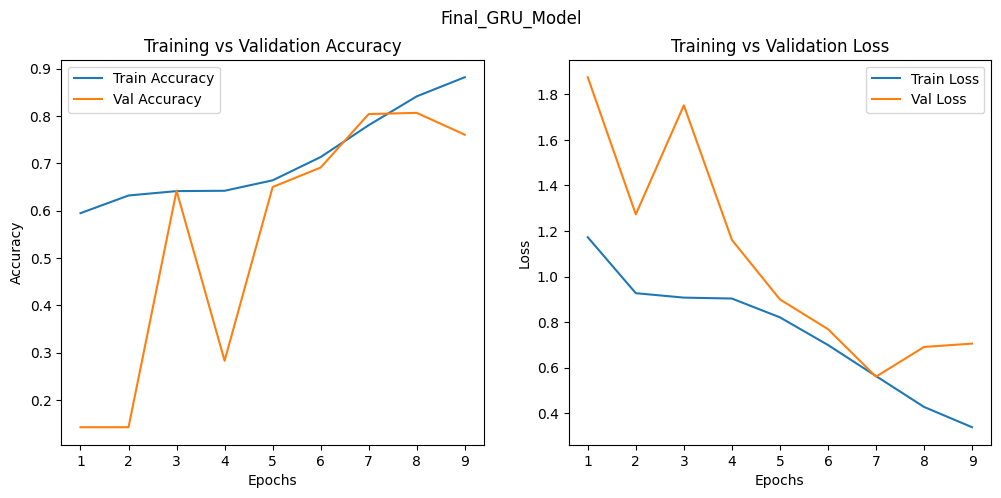

,accuracy,loss,val_accuracy,val_loss
0,0.594668,1.172648,0.142304,1.874899
1,0.632018,0.927085,0.142304,1.273015
2,0.641297,0.907603,0.642128,1.751524
3,0.642001,0.903595,0.282846,1.161018
4,0.664083,0.821069,0.649877,0.899811
5,0.713296,0.699756,0.691088,0.769298
6,0.780597,0.563399,0.804156,0.560604
7,0.841555,0.427892,0.806622,0.691040
8,0.881959,0.338822,0.760479,0.705788


In [17]:
plt.figure(figsize=(12,5))

# Accuracy subplot
plt.subplot(1,2,1)
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['accuracy'], label='Train Accuracy')
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['val_accuracy'], label='Val Accuracy')
# sns.lineplot(x=[5,5],y = [0.7,1],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

# Loss subplot
plt.subplot(1,2,2)
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['loss'], label='Train Loss')
sns.lineplot(x=range(1, len(df_tf)+1), y=df_tf['val_loss'], label='Val Loss')
# sns.lineplot(x=[5,5],y = [0.3,0.7],linestyle='--', color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.suptitle('Final_GRU_Model')
plt.show()

df_tf

In [18]:
joblib.dump(Encoder_model_ft, 'Trasformer_fastetxt.pkl')

['Trasformer_fastetxt.pkl']